<div style="background: linear-gradient(135deg, #4F46E5 0%, #7E22CE 100%);
            color: #FFFFFF; padding: 28px 32px; border-radius: 14px;
            font-family: 'IBM Plex Sans', 'Segoe UI', sans-serif;">
  <div style="font-family: 'IBM Plex Mono', Consolas, monospace; font-size: 13px;
              letter-spacing: 2px; opacity: 0.85;">INF672 · MACHINE LEARNING · PROBABILIDAD</div>
  <h1 style="margin: 8px 0 6px 0; font-size: 30px; font-weight: 700;">Dos formas de medir el azar</h1>
  <div style="font-size: 16px; opacity: 0.92;">El enfoque <b>clásico</b> (contar) y el <b>frecuentista</b> (repetir) — con simulaciones</div>
</div>

---

## De qué trata este cuaderno

Hay más de una forma de responder a la pregunta *"¿qué tan probable es esto?"*. En este notebook exploramos las dos más antiguas y fundamentales, y lo hacemos **simulando**, no solo con fórmulas:

| | **Enfoque clásico** | **Enfoque frecuentista** |
|---|---|---|
| **El gesto** | Contar | Repetir y observar |
| **¿Cuándo?** | *Antes* de experimentar | *Durante* el experimento |
| **Necesita** | Que todo sea igual de posible (simetría) | Muchísimas repeticiones |
| **Nos da** | El valor exacto | Una *estimación* |
| **Experimento** | Suma de dos dados | Moneda y chincheta |

La idea es sentir **por qué existen dos enfoques**: el primero es exacto pero frágil (se rompe cuando no hay simetría), y justo ahí es donde el segundo toma el relevo — que es también donde vive el machine learning.

> **Cómo usar este notebook.** Ejecuta las celdas en orden, de arriba a abajo (`Shift + Enter`). Cada bloque de código va precedido de una explicación. No hace falta saber probabilidad de antemano: empezamos desde cero.

## Preparación

Cargamos las librerías y fijamos la identidad visual de la materia (paleta índigo/púrpura, coral para las advertencias). Ejecuta esta celda una sola vez.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import product
from collections import Counter

# --- Identidad visual INF672 "cuaderno científico" ---
INDIGO = "#4F46E5"   # primario
PURPURA = "#7E22CE"  # apoyo
CORAL  = "#F43F5E"   # errores / advertencias / énfasis
TINTA  = "#111827"   # texto
CELDA  = "#F9FAFB"   # fondo de celda
HAIRLINE = "#E5E7EB"

# Fuente incluida en matplotlib: funciona en cualquier equipo, sin instalar nada.
mpl.rcParams.update({
    "font.family": ["DejaVu Sans", "sans-serif"],
    "font.size": 11,
    "axes.facecolor": CELDA,
    "figure.facecolor": "white",
    "axes.edgecolor": HAIRLINE,
    "axes.labelcolor": TINTA,
    "axes.titlecolor": TINTA,
    "axes.titleweight": "bold",
    "xtick.color": TINTA,
    "ytick.color": TINTA,
    "axes.grid": True,
    "grid.color": HAIRLINE,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Semilla para que los resultados sean reproducibles (mismo azar en cada corrida).
rng = np.random.default_rng(672)

print("Entorno listo. Paleta INF672 cargada.")

Entorno listo. Paleta INF672 cargada.


---

# Parte 1 · El enfoque clásico: contar sin tirar

El enfoque clásico calcula la probabilidad **antes de experimentar**, con pura aritmética:

$$P(\text{evento}) = \frac{\text{número de resultados favorables}}{\text{número total de resultados posibles}}$$

"Favorables" no significa "buenos", significa "los que cumplen lo que preguntas". Contar arriba, contar abajo, dividir. Eso es todo — **pero con una condición que lo es todo**, y que veremos en un momento.

## La pregunta

> **¿Cuál es la probabilidad de que la suma de dos dados sea 7?**

Antes de calcular nada, apuesta mentalmente. Un razonamiento muy común es:

<div style="border-left: 4px solid #F43F5E; background: #FEF2F4; padding: 12px 16px; border-radius: 0 8px 8px 0; font-family: 'IBM Plex Sans', 'Segoe UI', sans-serif;">
<b style="color:#F43F5E; font-family:'IBM Plex Mono',Consolas,monospace; font-size:12px; letter-spacing:1px;">⚠ RESPUESTA INGENUA</b><br>
"Las sumas posibles van de 2 a 12, o sea 11 valores distintos. Entonces P(7) = 1/11 ≈ 0.091."
</div>

Esta respuesta está **mal**. Y lo bonito es que el propio enfoque clásico, bien aplicado, es lo que revela el error. Vamos a verlo.

## Paso 1 — Enumerar el espacio muestral

El error de "1/11" es asumir que las **sumas** son igual de posibles. No lo son. Lo que *sí* es igual de posible es cada **par de dados** (dado 1, dado 2). Hay $6 \times 6 = 36$ pares, y cada uno tiene exactamente la misma probabilidad, $1/36$.

Generemos esos 36 pares y veámoslos completos.

In [2]:
# Todos los pares posibles (d1, d2) con cada dado de 1 a 6.
espacio_muestral = list(product(range(1, 7), repeat=2))  # 36 pares (d1, d2)
print(f"Total de resultados equiprobables: {len(espacio_muestral)}\n")

# Los mostramos como una rejilla 6x6 para verlos todos de un vistazo.
for d1 in range(1, 7):
    fila = "  ".join(f"({d1},{d2})" for d2 in range(1, 7))
    print(fila)

Total de resultados equiprobables: 36

(1,1)  (1,2)  (1,3)  (1,4)  (1,5)  (1,6)
(2,1)  (2,2)  (2,3)  (2,4)  (2,5)  (2,6)
(3,1)  (3,2)  (3,3)  (3,4)  (3,5)  (3,6)
(4,1)  (4,2)  (4,3)  (4,4)  (4,5)  (4,6)
(5,1)  (5,2)  (5,3)  (5,4)  (5,5)  (5,6)
(6,1)  (6,2)  (6,3)  (6,4)  (6,5)  (6,6)


Cada una de esas 36 casillas es un resultado con probabilidad $1/36$. **Ahí** vive la equiprobabilidad, no en las sumas.

## Paso 2 — Contar los casos favorables

Ahora sí aplicamos la fórmula clásica. Para cada suma posible (de 2 a 12), contamos **cuántos pares la producen** y dividimos entre 36.

Fíjate en la suma 7: se logra de seis maneras — (1,6), (2,5), (3,4), (4,3), (5,2), (6,1). En cambio la suma 2 solo de una: (1,1).

In [3]:
# Contamos cuántos pares dan cada suma.
conteo = Counter(d1 + d2 for d1, d2 in espacio_muestral)

print(f"{'Suma':>5} {'Pares favorables':>17} {'Probabilidad':>14}")
print("-" * 40)
for suma in range(2, 13):
    favorables = conteo[suma]
    prob = favorables / 36
    print(f"{suma:>5} {favorables:>17} {prob:>10.4f}  ({favorables}/36)")

# La respuesta a nuestra pregunta:
print("-" * 40)
print(f"\nP(suma = 7) = {conteo[7]}/36 = {conteo[7]/36:.4f}  ≈  {conteo[7]/36:.1%}")
print(f"La respuesta ingenua decía 1/11 = {1/11:.4f}. ¡Bastante lejos!")

 Suma  Pares favorables   Probabilidad
----------------------------------------
    2                 1     0.0278  (1/36)
    3                 2     0.0556  (2/36)
    4                 3     0.0833  (3/36)
    5                 4     0.1111  (4/36)
    6                 5     0.1389  (5/36)
    7                 6     0.1667  (6/36)
    8                 5     0.1389  (5/36)
    9                 4     0.1111  (4/36)
   10                 3     0.0833  (3/36)
   11                 2     0.0556  (2/36)
   12                 1     0.0278  (1/36)
----------------------------------------

P(suma = 7) = 6/36 = 0.1667  ≈  16.7%
La respuesta ingenua decía 1/11 = 0.0909. ¡Bastante lejos!


La probabilidad real de sacar 7 es $6/36 \approx 16.7\%$, no el $9.1\%$ que sugería el "1/11". El 7 es, de hecho, **la suma más probable** — y no por casualidad, sino porque es la que más pares distintos puede formar.

## Paso 3 — La forma de la distribución

Grafiquemos las 11 probabilidades. Aparece una silueta triangular con pico en el 7: la marca de que las sumas centrales tienen muchas más formas de ocurrir que los extremos.

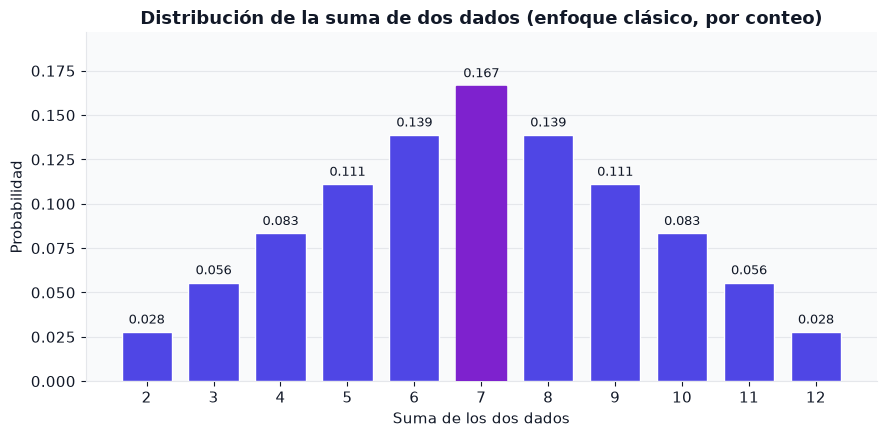

In [4]:
sumas = list(range(2, 13))
probs = [conteo[s] / 36 for s in sumas]

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.bar(sumas, probs, color=INDIGO, edgecolor="white", width=0.75, zorder=3)
# Resaltamos el máximo en púrpura.
barras[sumas.index(7)].set_color(PURPURA)

for s, p in zip(sumas, probs):
    ax.text(s, p + 0.003, f"{p:.3f}", ha="center", va="bottom", fontsize=9, color=TINTA)

ax.set_title("Distribución de la suma de dos dados (enfoque clásico, por conteo)")
ax.set_xlabel("Suma de los dos dados")
ax.set_ylabel("Probabilidad")
ax.set_xticks(sumas)
ax.set_ylim(0, max(probs) * 1.18)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## Paso 4 — Ver *por qué*, con un mapa de calor

El gráfico de barras muestra *qué* pasa; este mapa de calor muestra *por qué*. Cada celda es un par $(d_1, d_2)$ coloreada según su suma. Las **diagonales** agrupan pares con la misma suma — y la diagonal del 7 es la más larga (6 celdas), mientras que el 2 y el 12 quedan atrapados en una sola esquina.

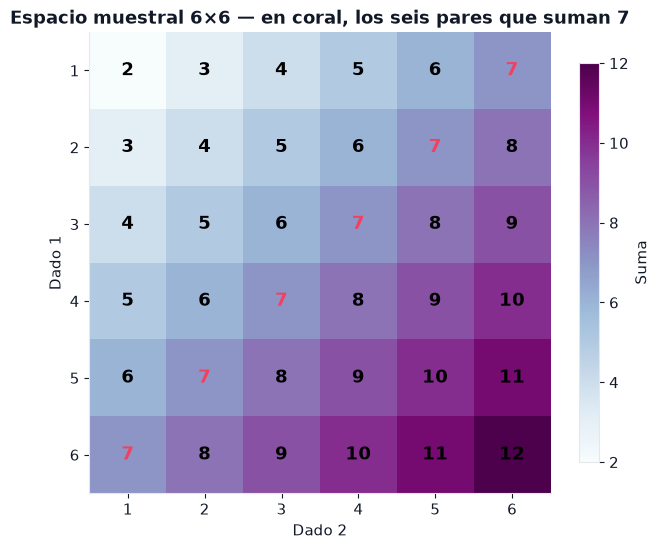

In [5]:
# Matriz 6x6 donde cada celda es la suma d1 + d2.
matriz = np.array([[d1 + d2 for d2 in range(1, 7)] for d1 in range(1, 7)])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(matriz, cmap="BuPu", origin="upper")

# Escribimos la suma dentro de cada celda; resaltamos las que suman 7.
for i in range(6):
    for j in range(6):
        es_siete = (matriz[i, j] == 7)
        ax.text(j, i, matriz[i, j], ha="center", va="center",
                color=CORAL if es_siete else "black",
                fontweight="bold", fontsize=13)

ax.set_xticks(range(6)); ax.set_xticklabels(range(1, 7))
ax.set_yticks(range(6)); ax.set_yticklabels(range(1, 7))
ax.set_xlabel("Dado 2"); ax.set_ylabel("Dado 1")
ax.set_title("Espacio muestral 6×6 — en coral, los seis pares que suman 7")
ax.grid(False)
plt.colorbar(im, ax=ax, label="Suma", shrink=0.85)
plt.tight_layout()
plt.show()

Se ve de un golpe: el 7 tiene la diagonal más larga. **Contar bien el espacio muestral equiprobable *es* el enfoque clásico** — y equivocarse al identificarlo (contar sumas en vez de pares) es lo que producía el "1/11".

## Paso 5 — Verificación: ¿y si tiramos de verdad?

Todo lo anterior fue aritmética *a priori*: no lanzamos ni un dado. Ahora, como puente hacia la Parte 2, vamos a **simular** miles de tiradas reales y superponer las frecuencias observadas sobre las probabilidades que calculamos por conteo.

El mensaje clave: el conteo ya había *predicho* el resultado sin necesidad de tirar. La simulación solo lo **confirma**.

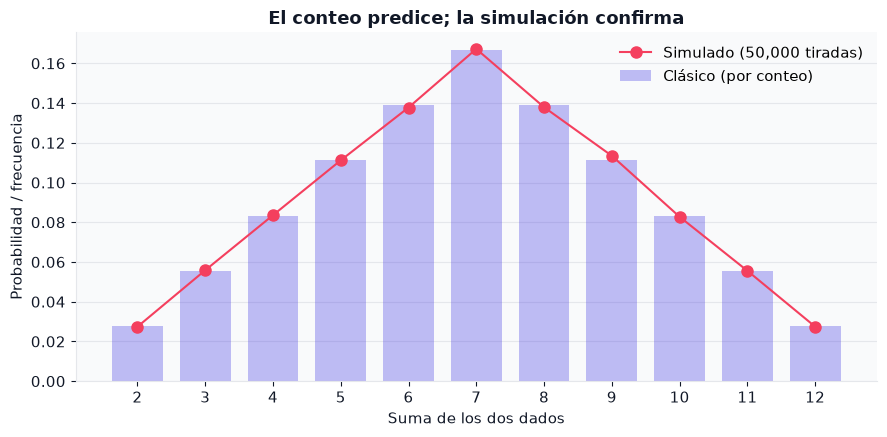

Los puntos (simulación) caen casi exactamente sobre las barras (conteo).


In [6]:
N = 50_000  # número de tiradas simuladas

# Tiramos N veces dos dados y sumamos.
d1 = rng.integers(1, 7, size=N)
d2 = rng.integers(1, 7, size=N)
sumas_simuladas = d1 + d2

# Frecuencia relativa observada de cada suma.
conteo_sim = Counter(sumas_simuladas)
frec_obs = [conteo_sim[s] / N for s in sumas]

fig, ax = plt.subplots(figsize=(9, 4.5))
# Barras: probabilidad teórica (clásica). Puntos: frecuencia simulada.
ax.bar(sumas, probs, color=INDIGO, alpha=0.35, width=0.75,
       label="Clásico (por conteo)", zorder=2)
ax.plot(sumas, frec_obs, "o-", color=CORAL, markersize=8, linewidth=1.5,
        label=f"Simulado ({N:,} tiradas)", zorder=3)

ax.set_title("El conteo predice; la simulación confirma")
ax.set_xlabel("Suma de los dos dados")
ax.set_ylabel("Probabilidad / frecuencia")
ax.set_xticks(sumas)
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print("Los puntos (simulación) caen casi exactamente sobre las barras (conteo).")

<div style="border-left: 4px solid #4F46E5; background: #EEF2FF; padding: 12px 16px; border-radius: 0 8px 8px 0; font-family: 'IBM Plex Sans','Segoe UI',sans-serif;">
<b style="color:#4F46E5; font-family:'IBM Plex Mono',Consolas,monospace; font-size:12px; letter-spacing:1px;">🔗 CONEXIÓN CON MACHINE LEARNING</b><br><br>
<b>Enumerar el espacio muestral y contar</b> es el gesto fundamental del razonamiento probabilístico; todo lo demás lo generaliza.<br><br>
El <b>supuesto de equiprobabilidad es un prior uniforme</b> — la misma idea que reaparecerá cuando veamos estimación bayesiana y MAP.<br><br>
Que una distribución <b>con forma</b> (la triangular) emerja de piezas <b>uniformes</b> (dados planos) prefigura cómo los modelos generativos construyen distribuciones complejas a partir de componentes simples.
</div>

---

## La pared contra la que choca el enfoque clásico

El enfoque clásico funcionó de maravilla con los dados. Pero mira **qué necesitó** para funcionar: que supiéramos, de antemano y con certeza, que los 36 pares eran igual de posibles. Esa **simetría** fue la que nos dejó contar y dividir.

Ahora una pregunta incómoda:

> Lanzo una **chincheta** (tachuela) al aire. Puede caer con la **punta hacia arriba** ↑ o **apoyada de lado** ⤾. ¿Cuál es la probabilidad de que caiga con la punta arriba?

¿1/2? **No hay ninguna razón para creerlo.** Una chincheta no es simétrica: su cabeza pesa distinto que su punta. No hay un espacio muestral parejo que enumerar, no hay simetría que explotar. El enfoque clásico se queda **mudo** — no porque lo apliquemos mal, sino porque *no hay forma* de aplicarlo.

Y aquí está lo importante: **este es el caso normal en el mundo real**, no la excepción. Casi nunca conocemos las probabilidades de antemano. Necesitamos otra manera de medir el azar — una que no cuente, sino que **repita y observe**. Esa es la Parte 2.

---

# Parte 2 · El enfoque frecuentista: repetir y observar

Cambiamos completamente de gesto. En vez de contar posibilidades antes de tirar, el enfoque frecuentista **define** la probabilidad como la frecuencia relativa a la que un evento ocurre cuando repites el experimento muchísimas veces:

$$P(A) = \lim_{n \to \infty} \frac{\text{veces que ocurrió } A}{n}$$

En palabras llanas: **tira muchas veces, cuenta qué fracción salió, y esa fracción es tu probabilidad.** Con una trampa honesta: nunca llegamos a infinito, así que siempre obtenemos una **estimación**, nunca el valor perfecto. Esa limitación no es un defecto que esconder — es exactamente la condición en la que vive el machine learning.

Lo probaremos en dos actos: primero en terreno conocido (una moneda, para ganar confianza), luego en terreno nuevo (la chincheta, donde es la *única* salida).

## El gesto frecuentista, en una función

Definimos una función mínima que encarna la idea: repetir un experimento $N$ veces y devolver la **frecuencia relativa acumulada** del evento, tirada por tirada. Esa secuencia acumulada es lo que graficaremos.

In [7]:
def frecuencia_acumulada(resultados):
    '''Dada una secuencia de 0s y 1s (0 = no ocurrió, 1 = ocurrió el evento),
    devuelve la fracción acumulada de 1s tras cada tirada.

    Ej.: [1,0,1,1] -> [1/1, 1/2, 2/3, 3/4] = [1.0, 0.5, 0.667, 0.75]
    '''
    resultados = np.asarray(resultados)
    aciertos_acumulados = np.cumsum(resultados)      # 1,1,2,3...
    tiradas = np.arange(1, len(resultados) + 1)      # 1,2,3,4...
    return aciertos_acumulados / tiradas

# Prueba rápida:
print(frecuencia_acumulada([1, 0, 1, 1]))

[1.         0.5        0.66666667 0.75      ]


## Acto 1 — La moneda: ganar confianza

Empezamos con una moneda justa, donde ya *sabemos* la respuesta ($P(\text{cara}) = 0.5$) gracias al enfoque clásico. Si el método frecuentista es bueno, debería converger solito a ese 0.5.

Simulamos 10 000 lanzamientos y graficamos cómo la frecuencia acumulada de caras se va estabilizando. Al principio salta como loca; luego se calma.

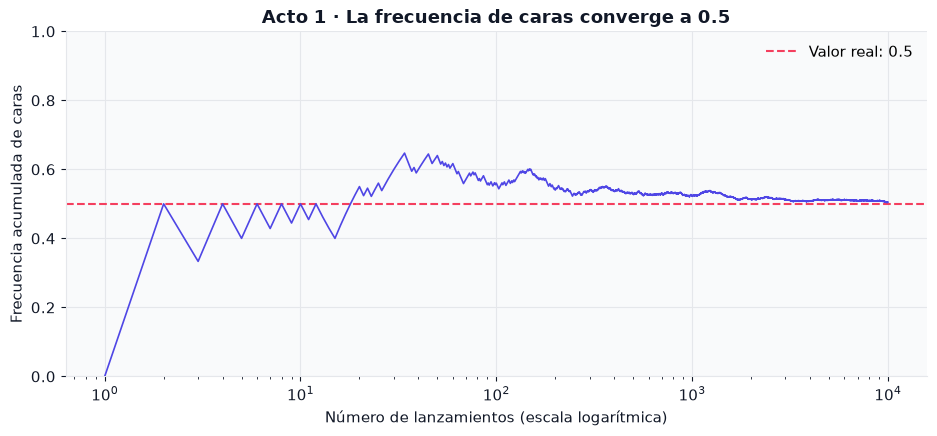

Con 10,000 lanzamientos, la estimación final fue 0.5049 (el valor real es 0.5).


In [8]:
N = 10_000
# 1 = cara, 0 = cruz. Moneda justa: prob 0.5.
lanzamientos = rng.integers(0, 2, size=N)
frec = frecuencia_acumulada(lanzamientos)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(np.arange(1, N + 1), frec, color=INDIGO, linewidth=1.2, zorder=3)
ax.axhline(0.5, color=CORAL, linestyle="--", linewidth=1.5,
           label="Valor real: 0.5", zorder=2)
ax.set_xscale("log")  # escala log en X para ver bien el caos inicial y la calma final
ax.set_title("Acto 1 · La frecuencia de caras converge a 0.5")
ax.set_xlabel("Número de lanzamientos (escala logarítmica)")
ax.set_ylabel("Frecuencia acumulada de caras")
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Con {N:,} lanzamientos, la estimación final fue {frec[-1]:.4f} (el valor real es 0.5).")

**Lo importante del Acto 1 no es descubrir un número nuevo** — ya sabíamos que era 0.5. Es *comprobar que el procedimiento funciona*: repetir y observar nos devuelve la misma respuesta que el conteo clásico. Ahora podemos confiar en él para usarlo donde el clásico no llega.

## Acto 2 — La chincheta: la necesidad

Ahora el caso que dejó mudo al enfoque clásico. Con la chincheta **no hay fórmula posible**: la única forma de conocer $P(\text{punta arriba})$ es lanzarla muchas veces y contar.

Para simularlo honestamente montamos un pequeño juego:

- La "naturaleza" tiene una probabilidad **verdadera y secreta** de que la chincheta caiga con la punta arriba. La fijamos abajo, pero imagina que **no la conoces**.
- Nuestro "experimento" solo ve resultados: 1 (punta arriba) o 0 (de lado). **Nunca ve el número secreto.**
- Estimamos por frecuencia, y **recién al final revelamos** el valor real para ver qué tan cerca quedamos.

In [9]:
# --- La naturaleza (secreto): NO mirar este número al razonar ---
P_VERDADERA = 0.62   # probabilidad real de "punta arriba" — desconocida para nosotros

N = 10_000
# La chincheta cae 'punta arriba' (1) con prob P_VERDADERA. Solo vemos 0s y 1s.
chinchetas = (rng.random(N) < P_VERDADERA).astype(int)
frec = frecuencia_acumulada(chinchetas)

estimacion = frec[-1]
print(f"Tras {N:,} lanzamientos, estimamos P(punta arriba) ≈ {estimacion:.4f}")
print("(Todavía sin mirar el valor real...)")

Tras 10,000 lanzamientos, estimamos P(punta arriba) ≈ 0.6192
(Todavía sin mirar el valor real...)


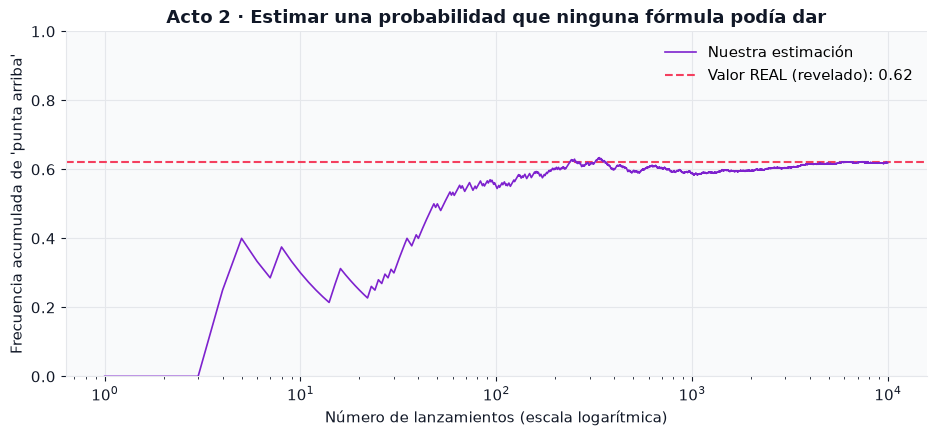

Estimación final: 0.6192  |  Valor real: 0.62  |  Error: 0.0008


In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(np.arange(1, N + 1), frec, color=PURPURA, linewidth=1.2,
        label="Nuestra estimación", zorder=3)
ax.axhline(P_VERDADERA, color=CORAL, linestyle="--", linewidth=1.5,
           label=f"Valor REAL (revelado): {P_VERDADERA}", zorder=2)
ax.set_xscale("log")
ax.set_title("Acto 2 · Estimar una probabilidad que ninguna fórmula podía dar")
ax.set_xlabel("Número de lanzamientos (escala logarítmica)")
ax.set_ylabel("Frecuencia acumulada de 'punta arriba'")
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Estimación final: {estimacion:.4f}  |  Valor real: {P_VERDADERA}  |  Error: {abs(estimacion - P_VERDADERA):.4f}")

Ese 0.62 **no salió de ninguna fórmula** — salió de los datos. Y así es exactamente como funciona el aprendizaje automático: la naturaleza tiene una distribución verdadera que nunca vemos directamente; solo tenemos muestras, y estimamos a partir de ellas.

## El experimento de la fragilidad — ¿cuántos datos hacen falta?

La estimación frecuentista tiene una debilidad crítica que conviene sentir ahora: **con pocas repeticiones, es un desastre poco confiable.** Comparemos la estimación de la chincheta con distintos tamaños de muestra.

In [11]:
tamaños = [10, 100, 1_000, 10_000, 100_000]

print(f"{'N (lanzamientos)':>18} {'Estimación':>12} {'Error':>10}")
print("-" * 44)
estimaciones = []
for n in tamaños:
    muestra = (rng.random(n) < P_VERDADERA).astype(int)
    est = muestra.mean()
    estimaciones.append(est)
    print(f"{n:>18,} {est:>12.4f} {abs(est - P_VERDADERA):>10.4f}")
print("-" * 44)
print(f"{'valor real':>18} {P_VERDADERA:>12.4f}")

  N (lanzamientos)   Estimación      Error
--------------------------------------------
                10       0.4000     0.2200
               100       0.5600     0.0600
             1,000       0.6090     0.0110
            10,000       0.6156     0.0044
           100,000       0.6206     0.0006
--------------------------------------------
        valor real       0.6200


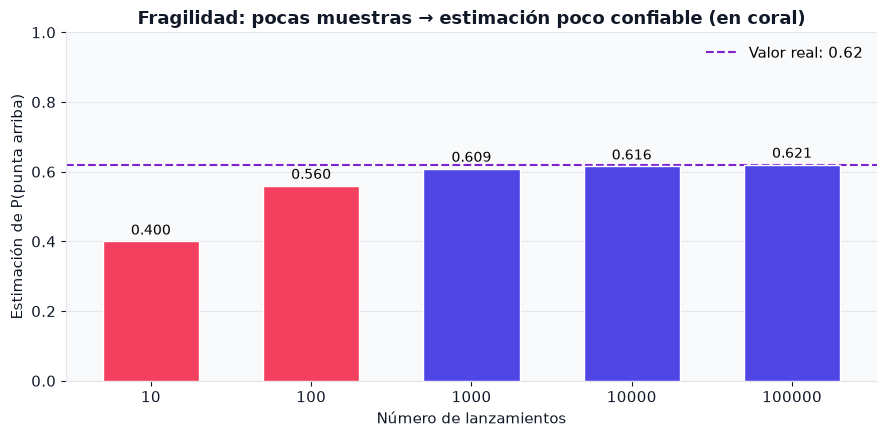

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colores = [CORAL if abs(e - P_VERDADERA) > 0.03 else INDIGO for e in estimaciones]
ax.bar([str(n) for n in tamaños], estimaciones, color=colores,
       edgecolor="white", zorder=3, width=0.6)
ax.axhline(P_VERDADERA, color=PURPURA, linestyle="--", linewidth=1.5,
           label=f"Valor real: {P_VERDADERA}")
for i, e in enumerate(estimaciones):
    ax.text(i, e + 0.01, f"{e:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Fragilidad: pocas muestras → estimación poco confiable (en coral)")
ax.set_xlabel("Número de lanzamientos")
ax.set_ylabel("Estimación de P(punta arriba)")
ax.set_ylim(0, 1)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Con $N=10$ la estimación puede estar clamorosamente lejos; con $N=100\,000$ es sólida como una roca. Ese es el precio del enfoque frecuentista: **necesita datos, y muchos.**

## Un detalle sutil: la estimación misma es azarosa

Una última cosa que enseña muchísimo. Si repetimos *toda* la simulación varias veces (con distintos "azares"), cada corrida traza un camino diferente hacia el valor real. Todas convergen al mismo sitio, pero por rutas ruidosas distintas.

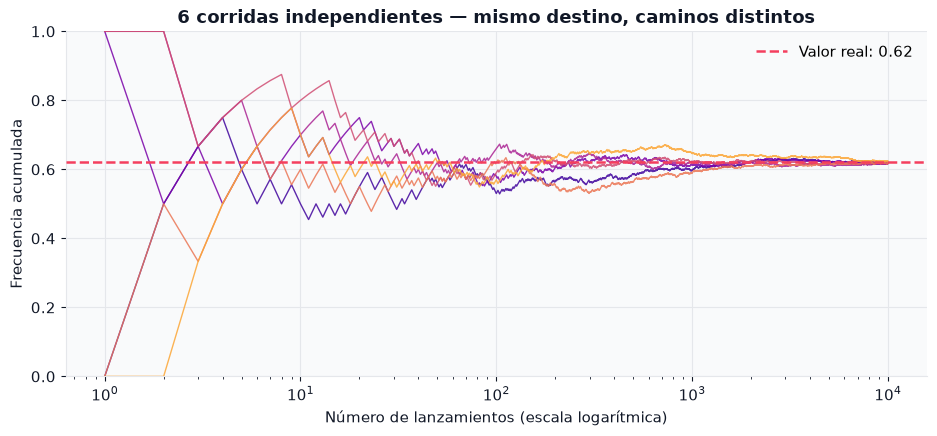

El límite es estable; el camino hacia él es azaroso. Estimar es, en sí mismo, incierto.


In [13]:
N = 10_000
n_corridas = 6

fig, ax = plt.subplots(figsize=(9.5, 4.5))
paleta = plt.cm.plasma(np.linspace(0.1, 0.8, n_corridas))

for k in range(n_corridas):
    # Cada corrida usa su propia semilla -> su propio ruido.
    rng_k = np.random.default_rng(k)
    muestra = (rng_k.random(N) < P_VERDADERA).astype(int)
    ax.plot(np.arange(1, N + 1), frecuencia_acumulada(muestra),
            color=paleta[k], linewidth=1.0, alpha=0.85, zorder=3)

ax.axhline(P_VERDADERA, color=CORAL, linestyle="--", linewidth=1.8,
           label=f"Valor real: {P_VERDADERA}", zorder=4)
ax.set_xscale("log")
ax.set_title(f"{n_corridas} corridas independientes — mismo destino, caminos distintos")
ax.set_xlabel("Número de lanzamientos (escala logarítmica)")
ax.set_ylabel("Frecuencia acumulada")
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("El límite es estable; el camino hacia él es azaroso. Estimar es, en sí mismo, incierto.")

<div style="border-left: 4px solid #4F46E5; background: #EEF2FF; padding: 12px 16px; border-radius: 0 8px 8px 0; font-family: 'IBM Plex Sans','Segoe UI',sans-serif;">
<b style="color:#4F46E5; font-family:'IBM Plex Mono',Consolas,monospace; font-size:12px; letter-spacing:1px;">🔗 CONEXIÓN CON MACHINE LEARNING</b><br><br>
<b>Entrenar un modelo es esto.</b> Estimar probabilidades y parámetros a partir de frecuencias observadas en los datos es, en esencia, lo que hace el aprendizaje. La <i>estimación por máxima verosimilitud</i> que veremos más adelante es literalmente "la frecuencia en los datos es tu mejor apuesta", formalizada.<br><br>
<b>La chincheta es el mundo real.</b> Nunca conoces las probabilidades verdaderas de la naturaleza; solo tienes una muestra y estimas. Vives en el Acto 2 permanentemente.<br><br>
<b>"Más datos ayuda" deja de ser un eslogan.</b> La curva de convergencia <i>es</i> la justificación visual de por qué los datasets grandes importan.<br><br>
<b>La fragilidad prefigura el sobreajuste.</b> Que la estimación con N=10 sea pésima y ruidosa es la primera cara de un problema que perseguirá todo el curso: estimar desde pocos datos es peligroso y de alta varianza.
</div>

---

# Síntesis: dos gestos para medir el azar

|  | **Clásico** (Parte 1) | **Frecuentista** (Parte 2) |
|---|---|---|
| **Cómo obtiene la probabilidad** | Cuenta casos favorables / totales | Repite el experimento y observa la frecuencia |
| **Cuándo** | *A priori*, antes de tirar | *A posteriori*, tirando |
| **Qué necesita** | Simetría (resultados equiprobables) | Muchas repeticiones (datos) |
| **Qué entrega** | El valor exacto | Una estimación (nunca perfecta) |
| **Se rompe cuando…** | No hay simetría (la chincheta) | Hay pocos datos (la fragilidad) |
| **Ejemplo del notebook** | Suma de dos dados | Moneda y chincheta |

Los dos enfoques no compiten: se **complementan**. El clásico es el ideal exacto cuando la simetría existe; el frecuentista es la herramienta práctica cuando no. Y como en machine learning casi nunca hay simetría conocida, **vivimos casi siempre en el mundo frecuentista** — estimando desde datos, con toda la incertidumbre que eso implica.

<div style="text-align:center; margin-top:24px; padding:14px; background:linear-gradient(135deg,#4F46E5 0%,#7E22CE 100%); border-radius:10px; color:white; font-family:'IBM Plex Mono',Consolas,monospace; font-size:13px; letter-spacing:1px;">
INF672 · MACHINE LEARNING · UATF
</div>